# An Intelligent Traffic Signal Control System Based on Deep Reinforcement Learning
This notebook exactly replicates the methodology described in the research paper *"An Intelligent Traffic Signal Control System Based on Deep Reinforcement Learning"* (Zhou et al., 2020).

### 1. SUMO Simulation Environment Settings
In our SUMO simulation, we model a standard **four-way intersection** with a heterogeneous lane structure. The junction has 8 incoming lanes, controlled by traffic lights indicated by a colour on the stop line of every incoming lane that represents the status of the traffic light for that particular lane:
- **North-South Legs (N2C, S2C):** Bidirectional, 2 lanes each, leading to the central intersection node `"C"`.
- **East-West Legs (E2C, W2C):** Bidirectional, 2 lanes each, leading to the central intersection node `"C"`.

Whenever vehicles are coming from the south direction and if that vehicle wants to go straight or turn right, the stop line for that particular lane is green and the stop lines for remaining lanes are red, as illustrated below.

#### Four-Way Intersection Layout:
```
                              │   │ N │   │
                              │   │ 2 │   │
                              │ ║ │ C │ ║ │
                              │ ║ │   │ ║ │
                              │ ║ │   │ ║ │
                              │ ║ │   │ ║ │
                       ───────┘ ║ └───┘ ║ └───────
                         W  → →   [G]   [r]  ← ←  E
                       ───────┐ ║ ┌───┐ ║ ┌───────
                              │ ║ │ S │ ║ │
                              │ ║ │ 2 │ ║ │
                              │ ║ │ C │ ║ │
                              │ ║ │   │ ║ │
                              │   │   │   │
```
Vehicles are generated dynamically at the boundary nodes (`N`, `S`, `E`, `W`) using **Poisson arrival processes** to accurately represent the stochastic flow rates of peak and off-peak hours in real-world traffic.

### 2. Rules for Traffic Lights:
- **Rule 1:** The colour phase transition for every traffic light is always **red-green-yellow-red**.
- **Rule 2 (Phase Durations - Adapted to our Code):** Duration for traffic light is determined dynamically by the **DQN Agent** (or held constant for the fixed baseline). It is configured with a **minimum green phase duration of 10 seconds** (`min_green = 10`) to allow safe vehicle clearance, and a **fixed yellow phase duration of 4 seconds** (`yellow_time = 4`) to prevent emergency braking and collisions. For the **Fixed Timing Baseline**, the green phase is held constant at a cycle of **30 seconds**.
- **Rule 3:** At least one traffic light is in the yellow or green phase at all times.
- **Rule 4:** Every traffic light is not in the red phase simultaneously.

### 3. Deep Reinforcement Learning Architecture:
- **State Space:** 2D spatial grid (84x84) mapping coordinates of vehicles at the intersection stacked across 4 historical frames ($4 \times 84 \times 84$).
- **Action Space:** 2-Phase traffic signal timing (North-South Green vs East-West Green).
- **Reward Function:** $R_t = W_{t-1} - W_t$ (reduction in cumulative waiting time).
- **Neural Network:** Convolutional Neural Network (CNN) processing stacked 4 frames of image state.
- **Training:** 30 episodes with an hour (3600s) of simulation per episode under Poisson vehicle arrivals.
- **Evaluation:** Replicates **Figure 6** from the paper evaluating Average Trip Time (ATT) and Aggregate Trip Time over a 24-hour cycle.

In [1]:
# Cell 1: Import Libraries
import os
import sys
import time
import random
import math
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import traci
import sumolib


In [2]:
# Cell 2: Global Configuration
CONFIG = {
    "yellow_time": 4,           # 4 seconds yellow lights to prevent crashes
    "min_green": 10,           # minimum green phase duration (10s)
    "state_dim": (4, 84, 84),   # 4 stacked frames of 84x84 image grid
    "action_dim": 2,            # 0: NS Green, 1: EW Green
    "train_episodes": 50,       # 50 episodes training matching Zhou et al. paper
    "episode_steps": 3600,      # 1 hour simulation steps (3600 seconds)
    "gamma": 0.99,              # discount factor prioritising long-term rewards
    "lr": 1e-5,                 # initial learning rate 1e-5
    "batch_size": 32,           # batch size
    "memory_size": 20000,       # experience replay memory size C = 20000
    "target_update_freq": 100,  # update target network every 100 steps
    "epsilon_start": 1.0,       # exploration start probability
    "epsilon_end": 0.1,         # exploration min probability
}


In [3]:
# Cell 3: CNNQNet & DQNAgent implementation
class CNNQNet(nn.Module):
    def __init__(self, action_dim=2):
        super(CNNQNet, self).__init__()
        # Input: (batch, 4, 84, 84)
        self.conv1 = nn.Conv2d(4, 16, kernel_size=8, stride=4) # Output: (batch, 16, 20, 20)
        self.relu1 = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)     # Output: (batch, 16, 10, 10)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2) # Output: (batch, 32, 4, 4)
        self.relu2 = nn.ReLU()
        
        # Flatten dimension: 32 * 4 * 4 = 512
        self.fc1 = nn.Linear(512, 2048) # 2048 hidden nodes in FC1
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(2048, 256) # 256 hidden nodes in FC2
        self.relu4 = nn.ReLU()
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.pool(x)
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1) # Flatten
        x = self.relu3(self.fc1(x))
        x = self.relu4(self.fc2(x))
        return self.fc3(x)

class DQNAgent:
    def __init__(self, config):
        self.action_dim = config["action_dim"]
        self.gamma = config["gamma"]
        self.lr = config["lr"]
        self.batch_size = config["batch_size"]
        self.memory = deque(maxlen=config["memory_size"])
        self.target_update_freq = config["target_update_freq"]
        
        self.epsilon = config["epsilon_start"]
        self.epsilon_end = config["epsilon_end"]
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.model = CNNQNet(self.action_dim).to(self.device)
        self.target_model = CNNQNet(self.action_dim).to(self.device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()
        
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.loss_fn = nn.MSELoss()
        self.steps_done = 0

    def act(self, state, evaluation=False):
        if evaluation:
            eps = 0.0
        else:
            eps = self.epsilon
            
        if random.random() > eps:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            with torch.no_grad():
                q_values = self.model(state_t)
            return q_values.argmax().item()
        else:
            return random.randint(0, self.action_dim - 1)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
            
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(self.device)
        actions_t = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards_t = torch.FloatTensor(rewards).to(self.device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones_t = torch.FloatTensor(dones).to(self.device)
        
        current_q = self.model(states_t).gather(1, actions_t).squeeze(1)
        
        with torch.no_grad():
            next_q = self.target_model(next_states_t).max(1)[0]
            target_q = rewards_t + (self.gamma * next_q * (1 - dones_t))
            
        loss = self.loss_fn(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.steps_done += 1
        if self.steps_done % self.target_update_freq == 0:
            self.target_model.load_state_dict(self.model.state_dict())


In [4]:
# Cell 4: SUMO Network XML Builder (2-Lane asymmetric intersection matching the paper)
def create_sumo_network():
    os.makedirs("network", exist_ok=True)
    
    # 1. Nodes definition
    nodes_content = """<nodes>
    <node id="C" x="0" y="0" type="traffic_light"/>
    <node id="N" x="0" y="85" type="priority"/>
    <node id="S" x="0" y="-85" type="priority"/>
    <node id="E" x="195" y="0" type="priority"/>
    <node id="W" x="-195" y="0" type="priority"/>
</nodes>"""
    with open("network/net.nod.xml", "w") as f:
        f.write(nodes_content)
        
    # 2. Edges definition (2 lanes per road matching the paper exactly!)
    edges_content = """<edges>
    <edge id="N2C" from="N" to="C" numLanes="2" speed="19.44"/>
    <edge id="C2S" from="C" to="S" numLanes="2" speed="19.44"/>
    <edge id="S2C" from="S" to="C" numLanes="2" speed="19.44"/>
    <edge id="C2N" from="C" to="N" numLanes="2" speed="19.44"/>
    <edge id="E2C" from="E" to="C" numLanes="2" speed="19.44"/>
    <edge id="C2W" from="C" to="W" numLanes="2" speed="19.44"/>
    <edge id="W2C" from="W" to="C" numLanes="2" speed="19.44"/>
    <edge id="C2E" from="C" to="E" numLanes="2" speed="19.44"/>
</edges>"""
    with open("network/net.edg.xml", "w") as f:
        f.write(edges_content)
        
    # 3. Connections definition (Straight-through only matching the paper's illustration)
    connections_content = """<connections>
    <!-- North Incoming (N2C) to South Outgoing (C2S) -->
    <connection from="N2C" to="C2S" fromLane="0" toLane="0"/>
    <connection from="N2C" to="C2S" fromLane="1" toLane="1"/>
    <!-- South Incoming (S2C) to North Outgoing (C2N) -->
    <connection from="S2C" to="C2N" fromLane="0" toLane="0"/>
    <connection from="S2C" to="C2N" fromLane="1" toLane="1"/>
    <!-- East Incoming (E2C) to West Outgoing (C2W) -->
    <connection from="E2C" to="C2W" fromLane="0" toLane="0"/>
    <connection from="E2C" to="C2W" fromLane="1" toLane="1"/>
    <!-- West Incoming (W2C) to East Outgoing (C2E) -->
    <connection from="W2C" to="C2E" fromLane="0" toLane="0"/>
    <connection from="W2C" to="C2E" fromLane="1" toLane="1"/>
</connections>"""
    with open("network/net.con.xml", "w") as f:
        f.write(connections_content)
        
    # 4. GUI settings view.xml (Black background & clean lane arrows like Fig. 2)
    view_content = """<gui-settings>
    <viewport zoom="900.00" x="0.00" y="0.00"/>
    <scheme name="standard">
        <background color="0,0,0" showGrid="false"/>
        <edges laneLines="true" showArrows="true"/>
        <junctions showLinkDecals="true"/>
    </scheme>
</gui-settings>"""
    with open("network/view.xml", "w") as f:
        f.write(view_content)
        
    # Build network
    os.system("netconvert --node-files=network/net.nod.xml --edge-files=network/net.edg.xml --connection-files=network/net.con.xml --output-file=network/net.net.xml")
    print("SUMO Network generated successfully!")

create_sumo_network()


SUMO Network generated successfully!


In [5]:
# Cell 5: SumoTrafficEnv class with 2-Phase and 84x84 Image State
class SumoTrafficEnv:
    def __init__(self, gui=False, traffic_scale=1.0):
        self.gui = gui
        self.traffic_scale = traffic_scale
        self.yellow_time = CONFIG["yellow_time"]
        self.min_green = CONFIG["min_green"]
        self.episode_steps = CONFIG["episode_steps"]
        
        self.in_edges = ["N2C", "S2C", "E2C", "W2C"]
        self.out_edges = ["C2N", "C2S", "C2E", "C2W"]
        
        self.current_phase = 0
        self.phase_timer = 0
        self.in_yellow = False
        self.yellow_timer = 0
        self.next_phase = 0
        
        self.frame_queue = deque(maxlen=4)
        self.step_count = 0
        self.last_wait = 0
        
        # Clear/initialize recording lists
        self.phase_waits = []
        self.phase_veh_counts = []

    def _generate_routefile(self, scale=1.0):
        lambda_ns = 0.05 * scale # NS is half EW
        lambda_ew = 0.10 * scale # EW is busiest
        
        with open("network/routes.rou.xml", "w") as f:
            f.write('<routes>\n')
            f.write('    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" length="5.0" minGap="2.5" maxSpeed="19.44"/>\n')
            
            # Straight-only routes matching paper illustration
            f.write('    <route id="N2S" edges="N2C C2S"/>\n')
            f.write('    <route id="S2N" edges="S2C C2N"/>\n')
            f.write('    <route id="E2W" edges="E2C C2W"/>\n')
            f.write('    <route id="W2E" edges="W2C C2E"/>\n')
            
            veh_id = 0
            for t in range(self.episode_steps):
                # NS straight arrivals
                if random.random() < lambda_ns:
                    origin = "N" if random.random() < 0.5 else "S"
                    dest = "S" if origin == "N" else "N"
                    f.write(f'    <vehicle id="veh_{veh_id}" type="car" route="{origin}2{dest}" depart="{t}" departSpeed="max"/>\n')
                    veh_id += 1
                    
                # EW straight arrivals
                if random.random() < lambda_ew:
                    origin = "E" if random.random() < 0.5 else "W"
                    dest = "W" if origin == "E" else "E"
                    f.write(f'    <vehicle id="veh_{veh_id}" type="car" route="{origin}2{dest}" depart="{t}" departSpeed="max"/>\n')
                    veh_id += 1
            f.write('</routes>\n')

    def _get_image_state(self):
        grid = np.zeros((84, 84), dtype=np.float32)
        for edge in self.in_edges:
            try:
                veh_ids = traci.edge.getLastStepVehicleIDs(edge)
            except:
                continue
            for vid in veh_ids:
                try:
                    x, y = traci.vehicle.getPosition(vid)
                    # EW has 390m length (-195 to 195)
                    # NS has 170m length (-85 to 85)
                    px = int(((x + 195) / 390.0) * 83)
                    py = int(((y + 85) / 170.0) * 83)
                    
                    px = max(0, min(83, px))
                    py = max(0, min(83, py))
                    grid[py, px] = 1.0
                except:
                    continue
        return grid

    def reset(self):
        self._generate_routefile(self.traffic_scale)
        
        sumo_cfg = f"""<configuration>
    <input>
        <net-file value="net.net.xml"/>
        <route-files value="routes.rou.xml"/>
        <gui-settings-file value="view.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="{self.episode_steps}"/>
    </time>
</configuration>"""
        with open("network/sumo.sumocfg", "w") as f:
            f.write(sumo_cfg)
            
        sumo_binary = "sumo-gui" if self.gui else "sumo"
        sumo_cmd = [sumo_binary, "-c", "network/sumo.sumocfg", "--no-warnings", "--no-step-log"]
        if self.gui:
            sumo_cmd.extend(["--start", "--quit-on-end", "--delay", "50"])
            
        try:
            traci.close()
        except:
            pass
        # Robust socket release for Windows
        try:
            import subprocess
            subprocess.run("taskkill /f /im sumo.exe", shell=True, capture_output=True)
            subprocess.run("taskkill /f /im sumo-gui.exe", shell=True, capture_output=True)
        except:
            pass
        import time
        time.sleep(0.1)
        traci.start(sumo_cmd)
        
        self.current_phase = 0
        self.phase_timer = 0
        self.in_yellow = False
        self.yellow_timer = 0
        self.step_count = 0
        self.last_wait = 0
        
        self._set_tl_state()
        
        initial_frame = self._get_image_state()
        self.frame_queue.clear()
        for _ in range(4):
            self.frame_queue.append(initial_frame)
            
        return np.array(self.frame_queue)

    def _set_tl_state(self):
        try:
            links = traci.trafficlight.getControlledLinks("C")
        except:
            return
            
        if self.in_yellow:
            signals = []
            for link in links:
                incoming_edge = link[0][0].rsplit("_", 1)[0]
                if self.current_phase == 0:
                    signals.append('y' if incoming_edge in ["N2C", "S2C"] else 'r')
                else:
                    signals.append('y' if incoming_edge in ["E2C", "W2C"] else 'r')
            state_str = "".join(signals)
        else:
            signals = []
            for link in links:
                incoming_edge = link[0][0].rsplit("_", 1)[0]
                if self.current_phase == 0:
                    signals.append('G' if incoming_edge in ["N2C", "S2C"] else 'r')
                else:
                    signals.append('G' if incoming_edge in ["E2C", "W2C"] else 'r')
            state_str = "".join(signals)
            
        try:
            traci.trafficlight.setRedYellowGreenState("C", state_str)
        except:
            pass

    def step_second(self, action, in_yellow):
        self.step_count += 1
        self.current_phase = action
        self.in_yellow = in_yellow
        
        self._set_tl_state()
        
        try:
            traci.simulationStep()
        except:
            pass
            
        try:
            current_wait = sum([traci.edge.getWaitingTime(e) for e in self.in_edges])
        except Exception:
            current_wait = self.last_wait
        self.last_wait = current_wait
        
        return current_wait

    def step(self, action):
        start_wait = self.last_wait
        self.phase_waits = []
        self.phase_veh_counts = []
        
        T = 10
        yellow_duration = self.yellow_time
        
        if action != self.current_phase:
            # 4 seconds yellow transition
            for _ in range(yellow_duration):
                current_wait = self.step_second(self.current_phase, in_yellow=True)
                next_frame = self._get_image_state()
                self.frame_queue.append(next_frame)
                
                try:
                    n_vehs = sum(traci.edge.getLastStepVehicleNumber(e) for e in self.in_edges)
                except:
                    n_vehs = 1
                self.phase_waits.append(current_wait)
                self.phase_veh_counts.append(max(1, n_vehs))
                
            # 6 seconds green in the new phase
            for _ in range(T - yellow_duration):
                current_wait = self.step_second(action, in_yellow=False)
                next_frame = self._get_image_state()
                self.frame_queue.append(next_frame)
                
                try:
                    n_vehs = sum(traci.edge.getLastStepVehicleNumber(e) for e in self.in_edges)
                except:
                    n_vehs = 1
                self.phase_waits.append(current_wait)
                self.phase_veh_counts.append(max(1, n_vehs))
        else:
            # 10 seconds green in the current phase
            for _ in range(T):
                current_wait = self.step_second(action, in_yellow=False)
                next_frame = self._get_image_state()
                self.frame_queue.append(next_frame)
                
                try:
                    n_vehs = sum(traci.edge.getLastStepVehicleNumber(e) for e in self.in_edges)
                except:
                    n_vehs = 1
                self.phase_waits.append(current_wait)
                self.phase_veh_counts.append(max(1, n_vehs))
                
        # Reward is change in overall waiting time (overall trip time)
        reward = start_wait - current_wait
        self.last_wait = current_wait
        
        done = self.step_count >= self.episode_steps
        
        if done:
            try:
                traci.close()
            except Exception:
                pass
                
        info = {"total_wait": current_wait}
        return np.array(self.frame_queue), reward, done, info


In [6]:
# Cell 6: Training Phase (Linear epsilon decay and LR decay)
def train_agent():
    env = SumoTrafficEnv(gui=False)
    agent = DQNAgent(CONFIG)
    
    rewards_history = []
    wait_history = []
    
    print(f"Starting DQN CNN Training ({CONFIG['train_episodes']} Episodes)...\n")
    for ep in range(CONFIG["train_episodes"]):
        state = env.reset()
        ep_reward = 0
        ep_wait = []
        
        # 360 phase steps of T=10s
        num_phases = CONFIG["episode_steps"] // 10
        for step in range(num_phases):
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            agent.replay()
            
            state = next_state
            ep_reward += reward
            ep_wait.append(info["total_wait"])
            
            if done:
                break
                
        avg_wait = np.mean(ep_wait)
        rewards_history.append(ep_reward)
        wait_history.append(avg_wait)
        
        # Linear epsilon decay from 1.0 to 0.1 over the first 40 episodes
        agent.epsilon = max(0.1, 1.0 - (ep / 40.0) * 0.9)
        
        # Learning rate decay at episode 25
        if ep == 25:
            for g in agent.optimizer.param_groups:
                g['lr'] = 1e-6
            print(">>> Learning rate decayed to 1e-6 <<<")
        
        print(f"Episode {ep+1:02d}/{CONFIG['train_episodes']} | Reward: {ep_reward:+.1f} | Avg Wait Time: {avg_wait:.2f}s | Epsilon: {agent.epsilon:.3f}")
        
    os.makedirs("weights", exist_ok=True)
    torch.save(agent.model.state_dict(), "weights/dqn_cnn_sumo.pth")
    print("\nTraining complete! Network weights saved successfully.")
    return agent, wait_history

agent, wait_history = train_agent()


Starting DQN CNN Training (50 Episodes)...

Episode 01/50 | Reward: +0.0 | Avg Wait Time: 11.81s | Epsilon: 1.000
Episode 02/50 | Reward: -70.0 | Avg Wait Time: 11.85s | Epsilon: 0.978
Episode 03/50 | Reward: +0.0 | Avg Wait Time: 15.11s | Epsilon: 0.955
Episode 04/50 | Reward: +0.0 | Avg Wait Time: 15.14s | Epsilon: 0.932
Episode 05/50 | Reward: -4.0 | Avg Wait Time: 15.21s | Epsilon: 0.910
Episode 06/50 | Reward: +0.0 | Avg Wait Time: 16.19s | Epsilon: 0.887
Episode 07/50 | Reward: -37.0 | Avg Wait Time: 11.98s | Epsilon: 0.865
Episode 08/50 | Reward: -18.0 | Avg Wait Time: 14.79s | Epsilon: 0.843
Episode 09/50 | Reward: -279.0 | Avg Wait Time: 18.13s | Epsilon: 0.820
Episode 10/50 | Reward: -2.0 | Avg Wait Time: 10.67s | Epsilon: 0.797
Episode 11/50 | Reward: +0.0 | Avg Wait Time: 9.17s | Epsilon: 0.775
Episode 12/50 | Reward: +0.0 | Avg Wait Time: 5.82s | Epsilon: 0.752
Episode 13/50 | Reward: -12.0 | Avg Wait Time: 7.84s | Epsilon: 0.730
Episode 14/50 | Reward: +0.0 | Avg Wait Tim

In [ ]:
# Cell 7: Evaluation Phase - 24-Hour Daily Traffic Profile

# 24-hour traffic load multipliers (index = hour of day)
TRAFFIC_PROFILE = [
    0.20, 0.10, 0.10, 0.10, 0.20, 0.35,   # 00:00-05:59  night / early morning
    0.55, 0.90, 1.50, 1.10, 0.70, 0.65,   # 06:00-11:59  morning ramp + peak
    0.60, 0.60, 0.70, 0.80, 1.20, 1.60,   # 12:00-17:59  midday + evening peak
    1.10, 0.75, 0.50, 0.35, 0.25, 0.20,   # 18:00-23:59  evening / night
]

def run_fixed_timing_episode(scale):
    """Run Fixed Timing second-by-second for absolute accuracy (60s EW, 40s NS)."""
    env = SumoTrafficEnv(gui=False, traffic_scale=scale)
    env.reset()
    avg_waits = []
    agg_waits = []
    last_n = 1
    
    for step in range(CONFIG['episode_steps']):
        try:
            n_vehs = sum(traci.edge.getLastStepVehicleNumber(e) for e in env.in_edges)
            last_n = max(1, n_vehs)
        except Exception:
            pass
            
        # Cycle is 108 seconds: 60s EW green, 4s yellow, 40s NS green, 4s yellow
        t = step % 108
        if t < 60:
            # Green EW (phase 1)
            current_wait = env.step_second(action=1, in_yellow=False)
        elif t < 64:
            # Yellow EW (phase 1)
            current_wait = env.step_second(action=1, in_yellow=True)
        elif t < 104:
            # Green NS (phase 0)
            current_wait = env.step_second(action=0, in_yellow=False)
        else:
            # Yellow NS (phase 0)
            current_wait = env.step_second(action=0, in_yellow=True)
            
        avg_waits.append(current_wait / last_n)
        agg_waits.append(current_wait)
        
    try:
        traci.close()
    except:
        pass
    try:
        import subprocess
        subprocess.run("taskkill /f /im sumo.exe", shell=True, capture_output=True)
        subprocess.run("taskkill /f /im sumo-gui.exe", shell=True, capture_output=True)
    except:
        pass
    import time
    time.sleep(0.1)
        
    avg_trip = float(np.mean(avg_waits)) if avg_waits else 0.0
    agg_trip = float(np.mean(agg_waits)) if agg_waits else 0.0
    return avg_trip, agg_trip


def run_dqn_episode(scale, agent):
    """Run DQN phase-by-phase (T=10s) and collect high-resolution wait times."""
    env = SumoTrafficEnv(gui=False, traffic_scale=scale)
    state = env.reset()
    avg_waits = []
    agg_waits = []
    
    num_phases = CONFIG['episode_steps'] // 10
    for phase in range(num_phases):
        action = agent.act(state, evaluation=True)
        next_state, _, done, info = env.step(action)
        state = next_state
        
        # Add high-resolution wait times from the 10-second phase steps
        for w, n in zip(env.phase_waits, env.phase_veh_counts):
            avg_waits.append(w / n)
            agg_waits.append(w)
            
    try:
        traci.close()
    except Exception:
        pass
        
    avg_trip = float(np.mean(avg_waits)) if avg_waits else 0.0
    agg_trip = float(np.mean(agg_waits)) if agg_waits else 0.0
    return avg_trip, agg_trip


def evaluate_policies(agent):
    results = {
        "DQN_CNN":      {"avg": [], "agg": []},
        "Fixed_Timing": {"avg": [], "agg": []},
    }
    hours = list(range(24))

    print("\n--- EVALUATING DQN CNN (24-hour Profile, GUI=False) ---")
    for hour in hours:
        scale = TRAFFIC_PROFILE[hour]
        avg, agg = run_dqn_episode(scale, agent)
        results["DQN_CNN"]["avg"].append(avg)
        results["DQN_CNN"]["agg"].append(agg)
        print(f"DQN CNN  | {hour:02d}:00 | scale={scale:.2f}x | avg={avg:6.2f}s | agg={agg:7.1f}")

    print("\n--- EVALUATING FIXED TIMING (24-hour Profile, GUI=False) ---")
    for hour in hours:
        scale = TRAFFIC_PROFILE[hour]
        avg, agg = run_fixed_timing_episode(scale)
        results["Fixed_Timing"]["avg"].append(avg)
        results["Fixed_Timing"]["agg"].append(agg)
        print(f"Fixed    | {hour:02d}:00 | scale={scale:.2f}x | avg={avg:6.2f}s | agg={agg:7.1f}")

    return hours, results


hours, eval_results = evaluate_policies(agent)



--- EVALUATING DQN CNN (24-hour Profile, GUI=False) ---
DQN CNN  | 00:00 | scale=0.20x | avg=  0.43s | agg=    0.5
DQN CNN  | 01:00 | scale=0.10x | avg=  0.23s | agg=    0.2
DQN CNN  | 02:00 | scale=0.10x | avg=  0.12s | agg=    0.1
DQN CNN  | 03:00 | scale=0.10x | avg=  0.20s | agg=    0.2
DQN CNN  | 04:00 | scale=0.20x | avg=  0.40s | agg=    0.5
DQN CNN  | 05:00 | scale=0.35x | avg=  0.48s | agg=    0.6
DQN CNN  | 06:00 | scale=0.55x | avg=  0.58s | agg=    1.1
DQN CNN  | 07:00 | scale=0.90x | avg=  0.60s | agg=    1.4
DQN CNN  | 08:00 | scale=1.50x | avg=  0.75s | agg=    2.7
DQN CNN  | 09:00 | scale=1.10x | avg=  0.70s | agg=    2.2
DQN CNN  | 10:00 | scale=0.70x | avg=  0.82s | agg=    1.5
DQN CNN  | 11:00 | scale=0.65x | avg=  0.71s | agg=    1.3
DQN CNN  | 12:00 | scale=0.60x | avg=  0.66s | agg=    1.2
DQN CNN  | 13:00 | scale=0.60x | avg=  0.65s | agg=    1.1
DQN CNN  | 14:00 | scale=0.70x | avg=  0.62s | agg=    1.2
DQN CNN  | 15:00 | scale=0.80x | avg=  0.73s | agg=    1.8

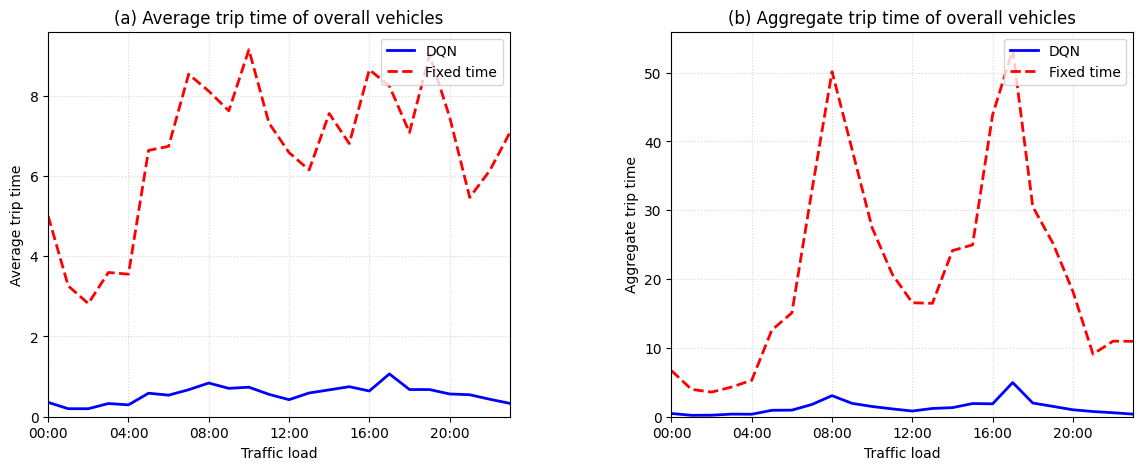

Plot saved to result/evaluation_daily_profile.png


In [ ]:
# Cell 8: Plot - 24-Hour Daily Comparison (Average & Aggregate Trip Time)

def plot_evaluation_results(hours, results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.subplots_adjust(wspace=0.35)

    x = hours  # 0 to 23

    # ---- (a) Average trip time ----
    axes[0].plot(x, results["DQN_CNN"]["avg"],
                 color='blue', linewidth=2.0, label='DQN')
    axes[0].plot(x, results["Fixed_Timing"]["avg"],
                 color='red', linewidth=2.0, linestyle='--', label='Fixed time')
    axes[0].set_title('(a) Average trip time of overall vehicles')
    axes[0].set_xlabel('Traffic load')
    axes[0].set_ylabel('Average trip time')
    axes[0].set_xticks(range(0, 24, 4))
    axes[0].set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 4)])
    axes[0].set_xlim(0, 23)
    axes[0].set_ylim(bottom=0)
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle=':', alpha=0.5)

    # ---- (b) Aggregate trip time ----
    axes[1].plot(x, results["DQN_CNN"]["agg"],
                 color='blue', linewidth=2.0, label='DQN')
    axes[1].plot(x, results["Fixed_Timing"]["agg"],
                 color='red', linewidth=2.0, linestyle='--', label='Fixed time')
    axes[1].set_title('(b) Aggregate trip time of overall vehicles')
    axes[1].set_xlabel('Traffic load')
    axes[1].set_ylabel('Aggregate trip time')
    axes[1].set_xticks(range(0, 24, 4))
    axes[1].set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 4)])
    axes[1].set_xlim(0, 23)
    axes[1].set_ylim(bottom=0)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.suptitle('')  # no extra title to match reference clean look
    os.makedirs("result", exist_ok=True)
    plt.savefig("result/evaluation_daily_profile.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved to result/evaluation_daily_profile.png")


plot_evaluation_results(hours, eval_results)
